<a class="cbe-colab-launch" href="https://colab.research.google.com/github/tlliuca/AI4ChemEng/blob/main/dsmles/participation/participation-09-nonlinear-methods.ipynb" target="_blank" rel="noopener noreferrer" title="Open this notebook in Google Colab (opens in a new tab)">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab" width="146" height="25">
</a>

In [ ]:
# Run this cell first in a fresh notebook environment.
%pip install -q "numpy<2.4" pandas matplotlib scikit-learn pycse shap xgboost umap-learn jupyterquiz==2.9.6.2 uncertainties

In [ ]:
# Included CBE 4427 data; no original-course server is contacted.
from pathlib import Path
import base64, json, tempfile, zlib
_course_embedded = json.loads(zlib.decompress(base64.b64decode('eNqrrgUAAXUA+Q==')))
_course_cache = Path(tempfile.mkdtemp(prefix="cbe4427-"))
def course_file(name):
    """Use a local course file, or the copy embedded in this notebook."""
    for root in [Path.cwd(), *Path.cwd().parents]:
        for candidate in [root / "dsmles" / name, root / name]:
            if candidate.is_file():
                return str(candidate)
    if name not in _course_embedded:
        raise FileNotFoundError("Course resource not included: " + name)
    target = (_course_cache / name).resolve()
    if _course_cache not in target.parents:
        raise ValueError("Invalid course resource path")
    target.parent.mkdir(parents=True, exist_ok=True)
    if not target.exists():
        target.write_text(_course_embedded[name])
    return str(target)


```{note}
Practice resource for CBE 4427. Your instructor specifies assigned activities, deadlines, submission requirements, and assessment criteria. Example points or rubrics below are part of the practice material.
```

# Module 09: Nonlinear Methods - Participation Exercises

## Exercise 9.1: Prediction - Method Selection

**Type:** 🔮 Prediction (3 min)

For each scenario, predict which method would work best: **Linear Regression**, **Polynomial Regression**, **Decision Tree**, or **k-Nearest Neighbors**.

| Scenario | Your Choice | Reasoning |
|----------|-------------|----------|
| Predicting yield from temperature (Arrhenius-like) | | |
| Classifying materials into 5 categories based on properties | | |
| Predicting property with many step-changes/thresholds | | |
| Predicting output from 100 features, most are noise | | |

*Fill in the table above*

## Exercise 9.2: Mini-Exercise - Overfitting Visualization

**Type:** 🔧 Mini-Exercise (7 min)

Visualize overfitting with polynomial regression.

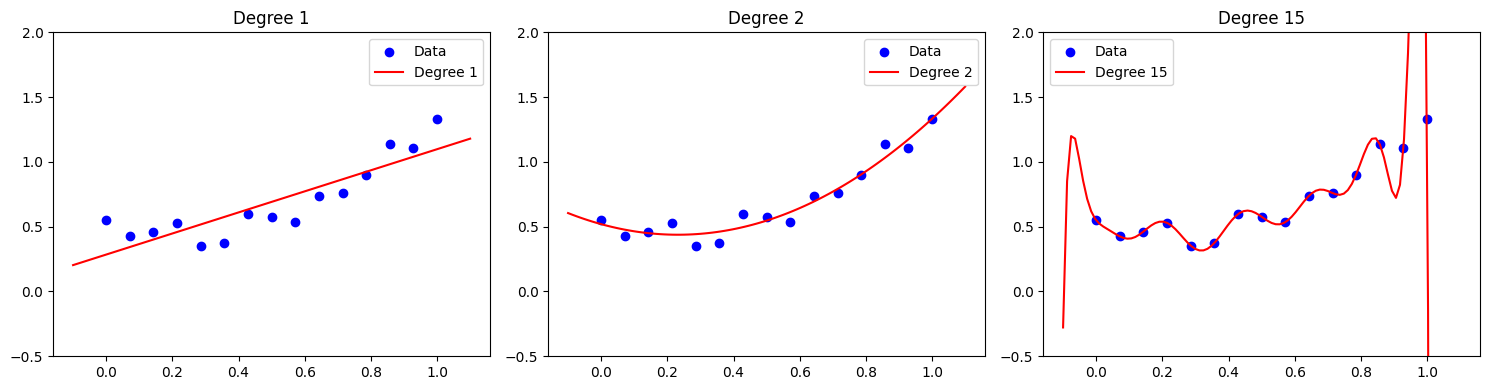

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

# Generate noisy data from a simple quadratic
np.random.seed(42)
X = np.linspace(0, 1, 15).reshape(-1, 1)
y = 2*X.ravel()**2 - X.ravel() + 0.5 + np.random.randn(15)*0.1

X_plot = np.linspace(-0.1, 1.1, 100).reshape(-1, 1)

plt.figure(figsize=(15, 4))

# TASK: Try degrees 1, 2, and 15
# For each, plot the fit and observe what happens
for i, degree in enumerate([1, 2, 15]):
    plt.subplot(1, 3, i+1)
    
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(X, y)
    
    plt.scatter(X, y, color='blue', label='Data')
    plt.plot(X_plot, model.predict(X_plot), color='red', label=f'Degree {degree}')
    plt.ylim(-0.5, 2)
    plt.title(f'Degree {degree}')
    plt.legend()

plt.tight_layout()
plt.show()

# QUESTION: Which degree is best? How do you know?

*Your observation:*



## Exercise 9.3: Discussion - Interpretability vs Performance

**Type:** 💬 Discussion (5 min)

You're presenting model results to plant operators who need to understand *why* the model makes certain predictions.

**Discuss:**
1. Rank these models from most to least interpretable: Linear Regression, Random Forest, Neural Network, Decision Tree
2. When might you sacrifice interpretability for performance?
3. How could you make a black-box model more interpretable?

*Discussion notes:*

